<a href="https://colab.research.google.com/github/Aouisssaoui-Zied/oil-price-time-series-analysis/blob/main/oil_price_time_series_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyse des Prix du Pétrole Brut — Time Series Analysis

**Auteur :** Aouissaoui Zied

**Dataset :** WTI Crude Oil Prices (1987-2024)

**Outils :** Python · Pandas · Matplotlib · Statsmodels

## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

## 2. Chargement des données

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/datasets/oil-prices/master/data/wti-daily.csv')
print(f"Dimensions : {df.shape}")
df.head()

Dimensions : (10153, 2)


,Date,Price
0,1986-01-02,25.56
1,1986-01-03,26.00
2,1986-01-06,26.53
3,1986-01-07,25.85
4,1986-01-08,25.87


In [3]:
print(df.dtypes)

Date      object
Price    float64
dtype: object


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
print(df.dtypes)
print(df.head())

Price    float64
dtype: object
            Price
Date             
1986-01-02  25.56
1986-01-03  26.00
1986-01-06  26.53
1986-01-07  25.85
1986-01-08  25.87


## 3. Exploration des données

In [5]:
print(df.index.min())
print(df.index.max())

1986-01-02 00:00:00
2026-05-04 00:00:00


### 3.1 Visualisation générale des prix du pétrole

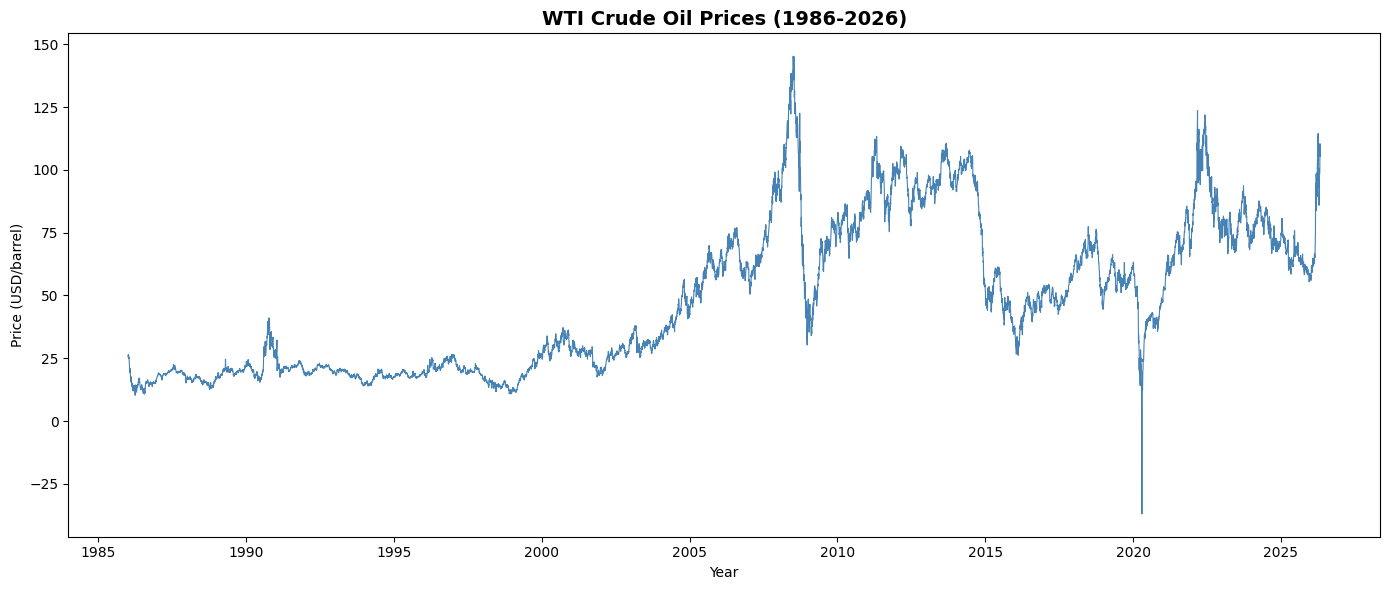

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Price'], color='steelblue', linewidth=0.8)
plt.title("WTI Crude Oil Prices (1986-2026)", fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Price (USD/barrel)')
plt.tight_layout()
plt.show()

### Interprétation

Les prix du pétrole étaient bas avant 2000 (environ 20$).
Après 2000, ils ont beaucoup augmenté et sont devenus très instables.

3 grandes chutes :
- 2009 : Crise financière mondiale
- 2015 : Trop de pétrole produit
- 2020 : COVID-19 → prix négatif (-37$)

## 4. Rolling Average — Lissage de la courbe

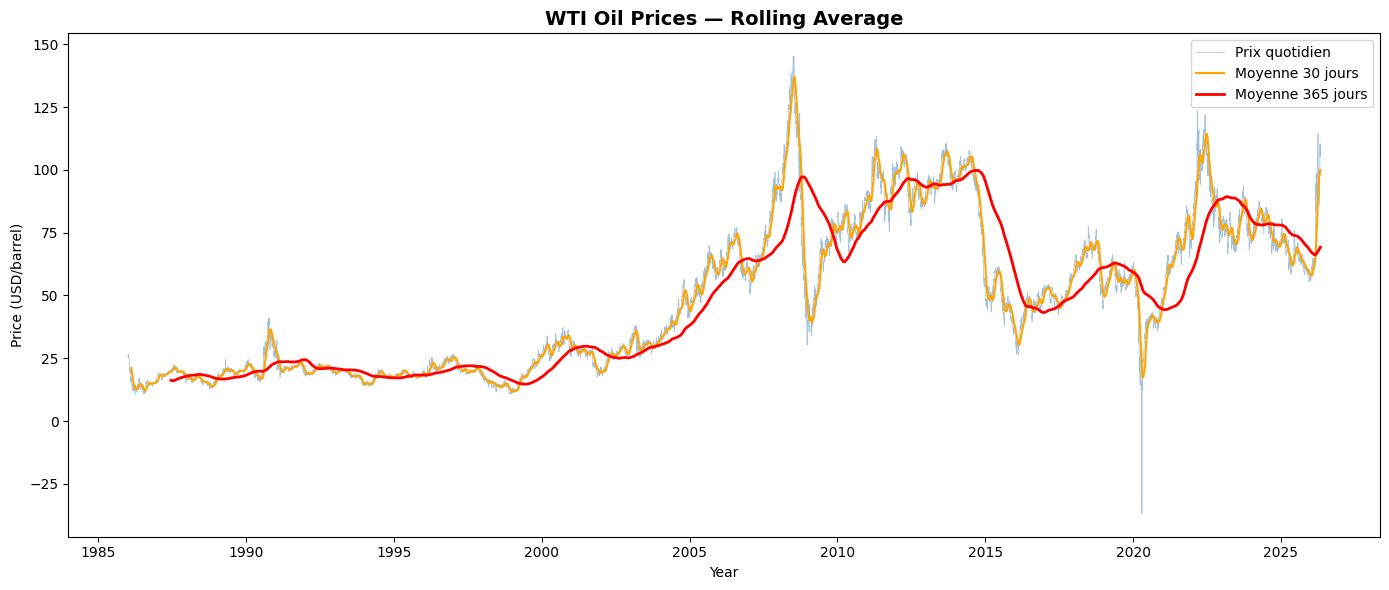

In [7]:
# Calcul du Rolling Average sur 30 et 365 jours
df['MA_30'] = df['Price'].rolling(window=30).mean()
df['MA_365'] = df['Price'].rolling(window=365).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Price'], color='steelblue',
         linewidth=0.5, alpha=0.5, label='Prix quotidien')
plt.plot(df.index, df['MA_30'], color='orange',
         linewidth=1.5, label='Moyenne 30 jours')
plt.plot(df.index, df['MA_365'], color='red',
         linewidth=2, label='Moyenne 365 jours')
plt.title('WTI Oil Prices — Rolling Average', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Price (USD/barrel)')
plt.legend()
plt.tight_layout()
plt.show()

### Interprétation
La moyenne 365 jours (rouge) révèle clairement la tendance générale,
en éliminant le bruit des fluctuations quotidiennes.

## 5. Décomposition de la série temporelle
La décomposition sépare la série en 3 composantes :
- **Trend** : La tendance générale (hausse ou baisse)
- **Seasonality** : Les cycles qui se répètent régulièrement
- **Residual** : Ce qui reste (bruit aléatoire)

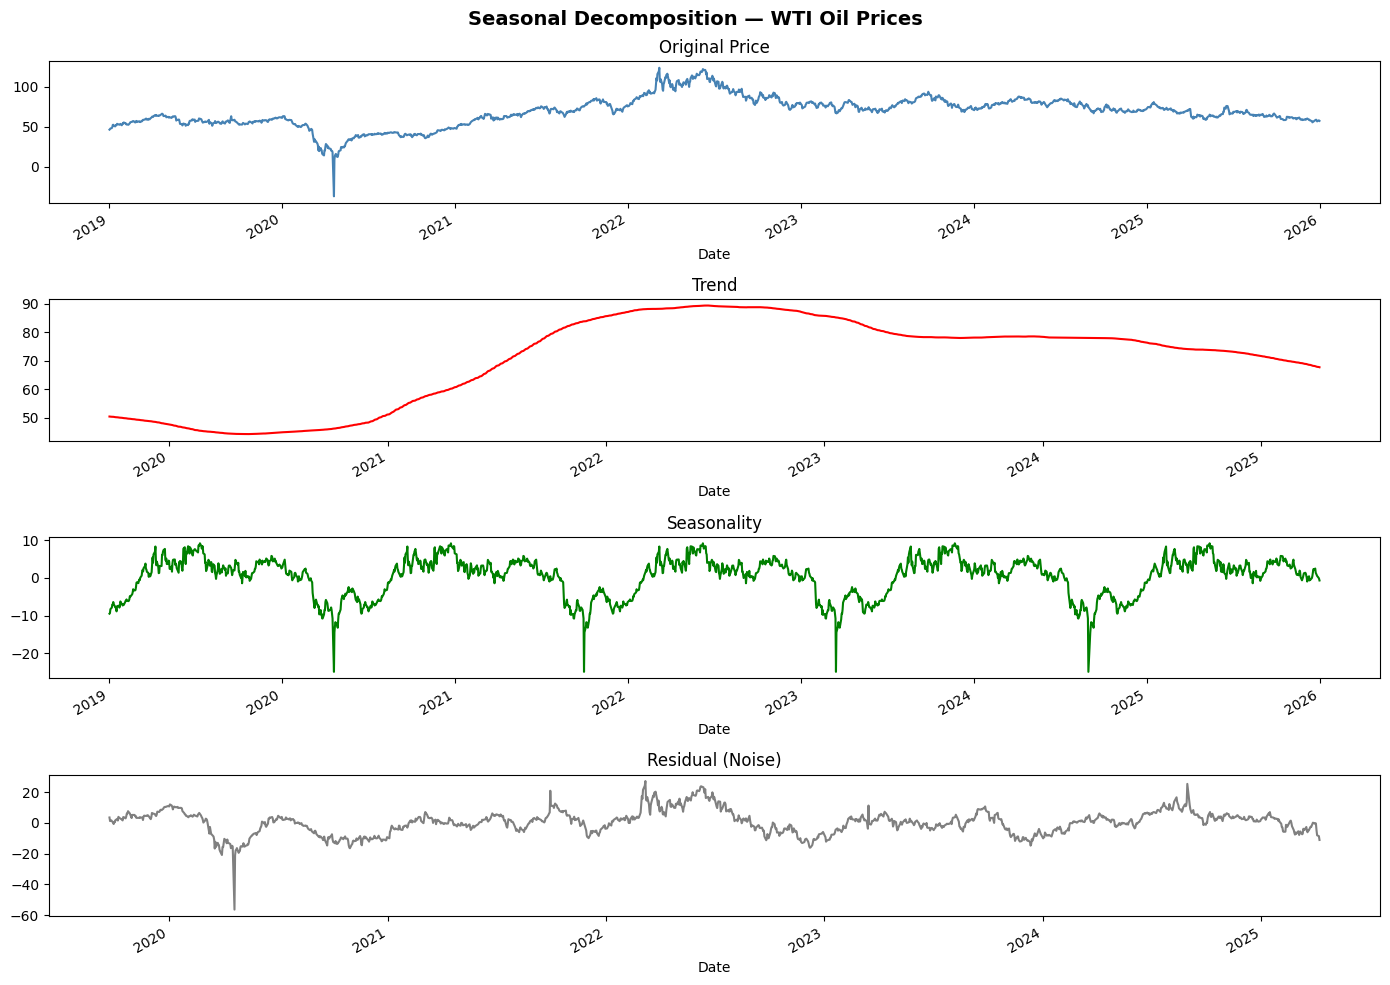

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Last 6 years only
df_recent=df['2019':'2025']
# Time series decomposition
decomposition = seasonal_decompose(df_recent['Price'],
                                   model='additive',
                                   period=365)
fig,axes = plt.subplots(4,1,figsize=(14,10))
fig.suptitle('Seasonal Decomposition — WTI Oil Prices', fontsize=14, fontweight='bold')
decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Original Price')

decomposition.trend.plot(ax=axes[1], color='red')
axes[1].set_title('Trend')

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Seasonality')

decomposition.resid.plot(ax=axes[3], color='gray')
axes[3].set_title('Residual (Noise)')

plt.tight_layout()
plt.show()

### Interprétation
- Trend : Baisse en 2020 (COVID), forte hausse en 2022 (guerre Ukraine),
  stabilisation autour de 80$ en 2023-2024
- Seasonality : Hausse en début d'année (hiver), baisse en milieu d'année
- Residual : Chute brutale avril 2020 (COVID-19 — événement imprévisible)

## 6. Forecasting — Prévision des prix futurs

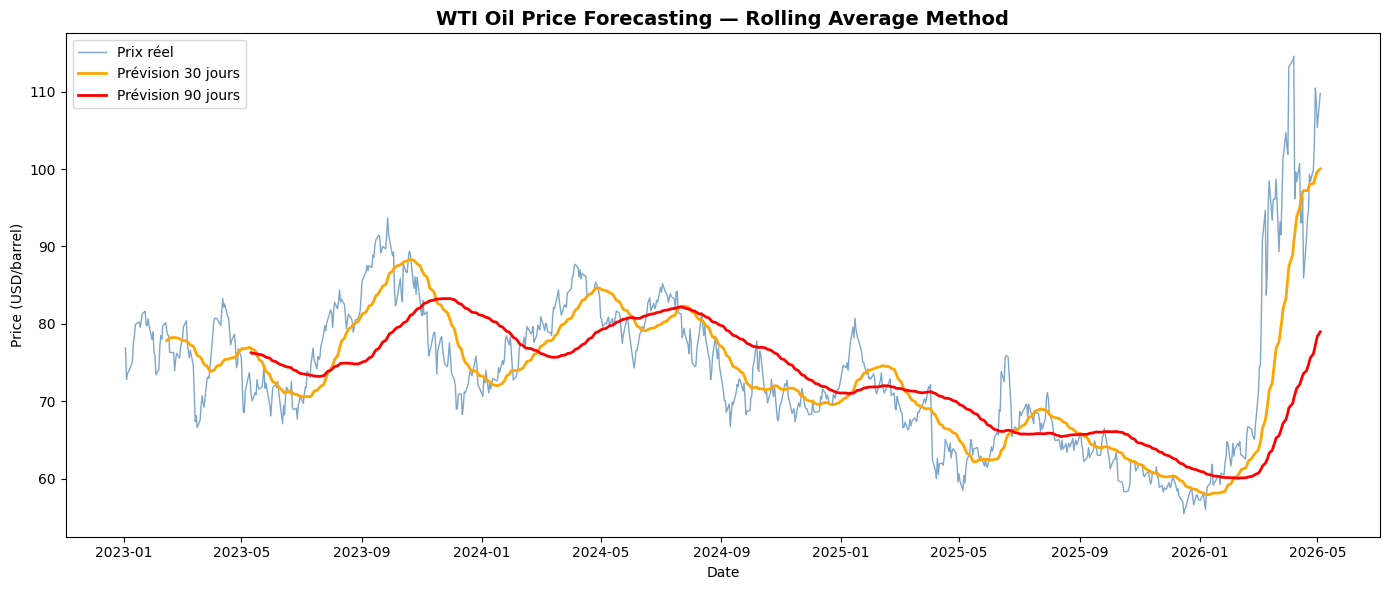

In [9]:
df_forecast = df['2023':'2026'].copy()
## Rolling average as forecast
df_forecast['MA_30'] = df_forecast['Price'].rolling(window=30).mean()
df_forecast['MA_90'] = df_forecast['Price'].rolling(window=90).mean()

plt.figure(figsize=(14, 6))
plt.plot(df_forecast.index, df_forecast['Price'],
         color='steelblue', linewidth=1, alpha=0.7, label='Prix réel')
plt.plot(df_forecast.index, df_forecast['MA_30'],
         color='orange', linewidth=2, label='Prévision 30 jours')
plt.plot(df_forecast.index, df_forecast['MA_90'],
         color='red', linewidth=2, label='Prévision 90 jours')
plt.title('WTI Oil Price Forecasting — Rolling Average Method',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD/barrel)')
plt.legend()
plt.tight_layout()
plt.show()

### Interprétation
La méthode Rolling Average suit bien la tendance générale,
mais elle ne peut pas prévoir les hausses/baisses soudaines.
La hausse brutale de 2026 n'a pas été anticipée par les deux moyennes.
→ Limitation principale : le "Lag" (retard).

## 7. Analyse des événements majeurs

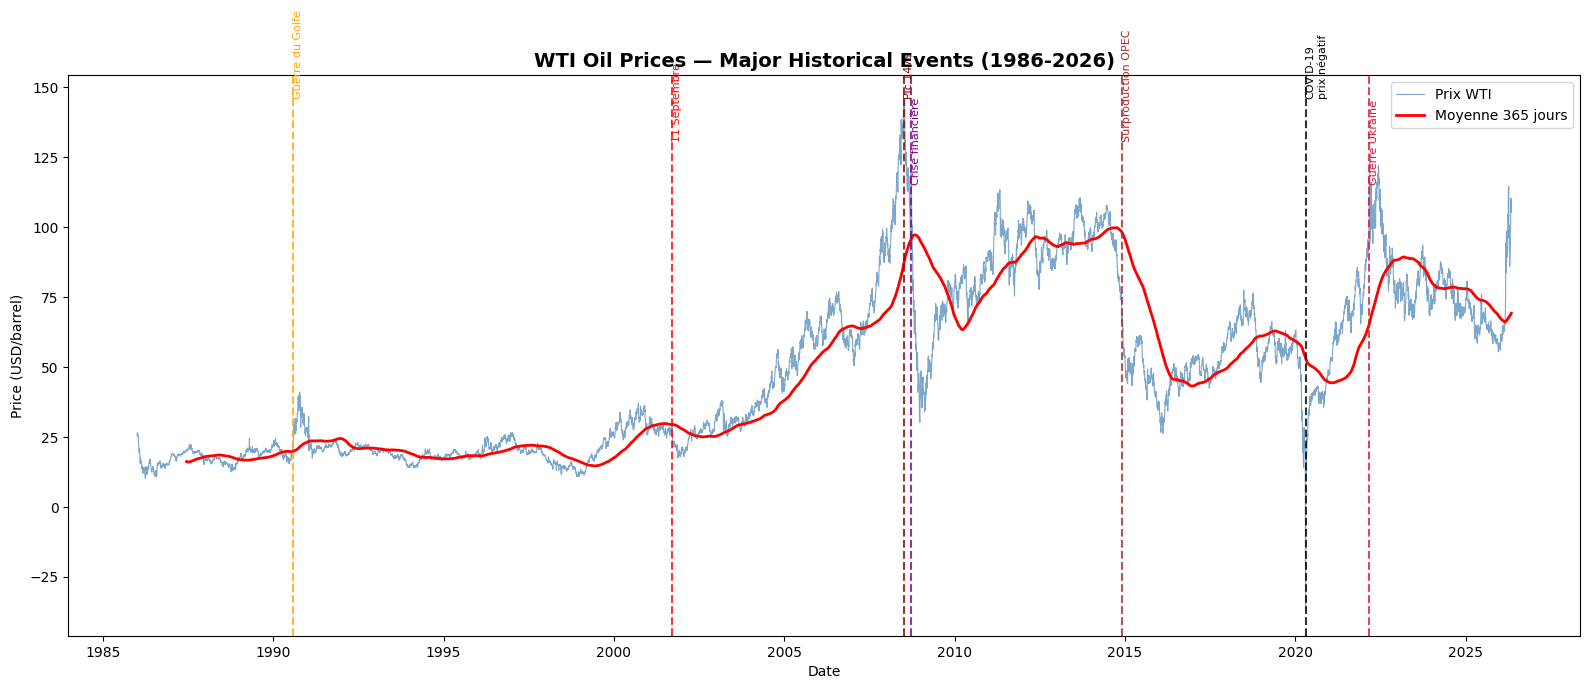

In [10]:

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(df.index, df['Price'], color='steelblue',
        linewidth=0.8, alpha=0.7, label='Prix WTI')
ax.plot(df.index, df['MA_365'], color='red',
        linewidth=2, label='Moyenne 365 jours')

# Événements majeurs
events = {
    '1990-08-02': ('Guerre du Golfe', 'orange', 0.95),
    '2001-09-11': ('11 Septembre', 'red', 0.85),
    '2008-07-03': ('Pic 147$', 'darkred', 0.95),
    '2008-09-15': ('Crise financière', 'purple', 0.75),
    '2014-11-27': ('Surproduction OPEC', 'brown', 0.85),
    '2020-04-20': ('COVID-19\nprix négatif', 'black', 0.95),
    '2022-02-24': ('Guerre Ukraine', 'crimson', 0.75),
}
for date, (label, color, height) in events.items():
    ax.axvline(x=pd.Timestamp(date), color=color,
               linestyle='--', linewidth=1.5, alpha=0.8)
    ax.text(pd.Timestamp(date), ax.get_ylim()[1]*height,
            label, rotation=90, fontsize=8, color=color)

ax.set_title('WTI Oil Prices — Major Historical Events (1986-2026)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD/barrel)')
ax.legend()
plt.tight_layout()
plt.show()

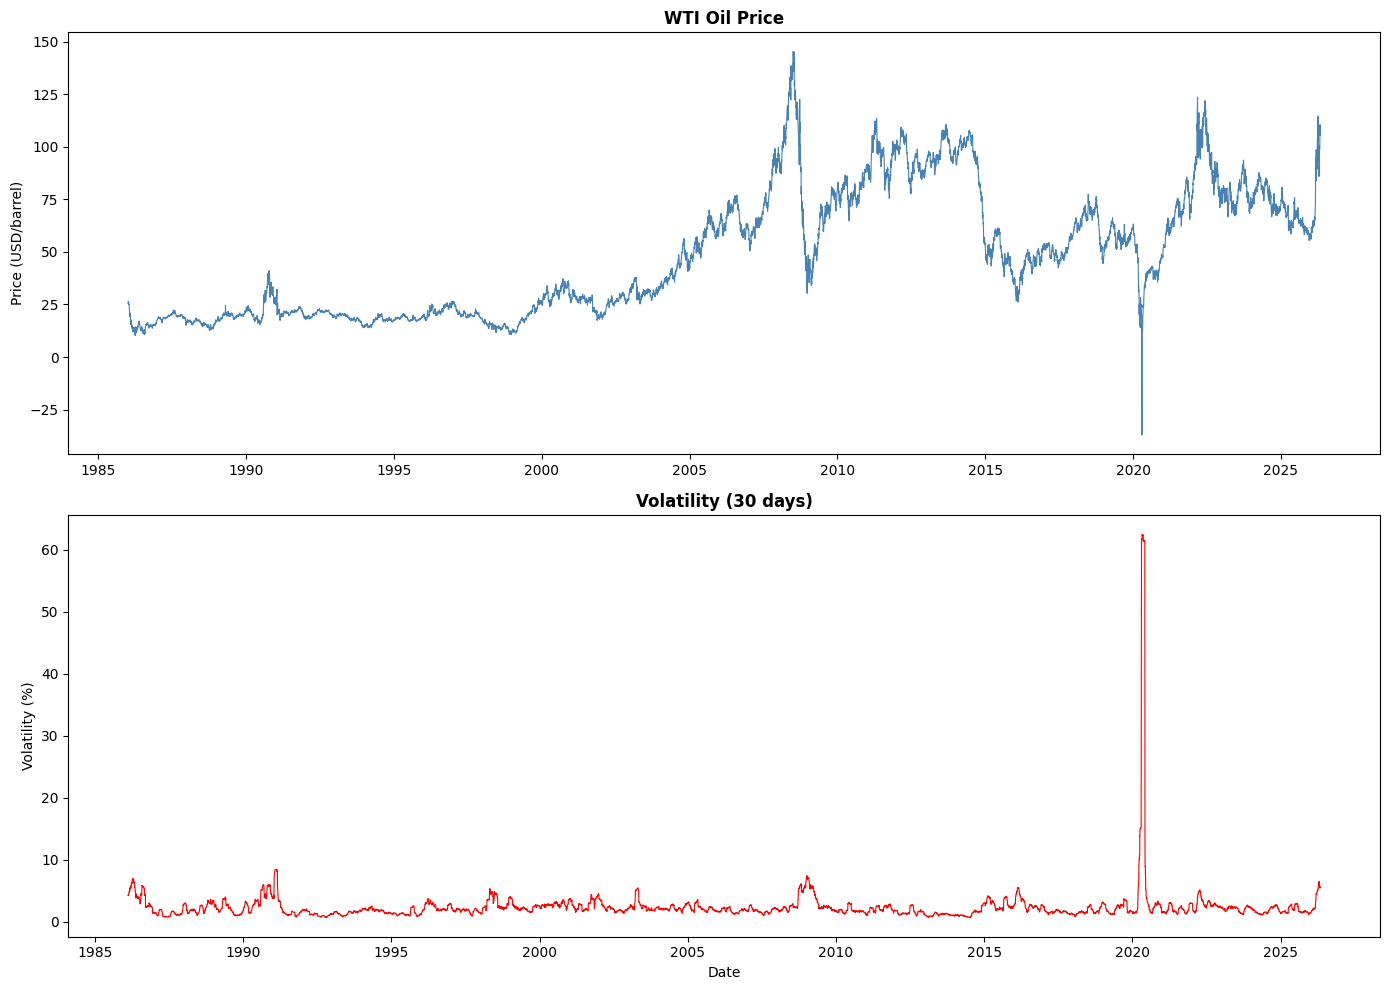

In [11]:
# Calcul de la volatilité quotidienne
df['daily_return'] = df['Price'].pct_change() * 100

# Volatilité sur 30 jours
df['volatility_30'] = df['daily_return'].rolling(window=30).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Rسم السعر
axes[0].plot(df.index, df['Price'], color='steelblue', linewidth=0.8)
axes[0].set_title('WTI Oil Price', fontweight='bold')
axes[0].set_ylabel('Price (USD/barrel)')

# رسم الـ Volatility
axes[1].plot(df.index, df['volatility_30'], color='red', linewidth=0.8)
axes[1].set_title('Volatility (30 days)', fontweight='bold')
axes[1].set_ylabel('Volatility (%)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

## 9. Trend Forecasting — Prévision par régression linéaire

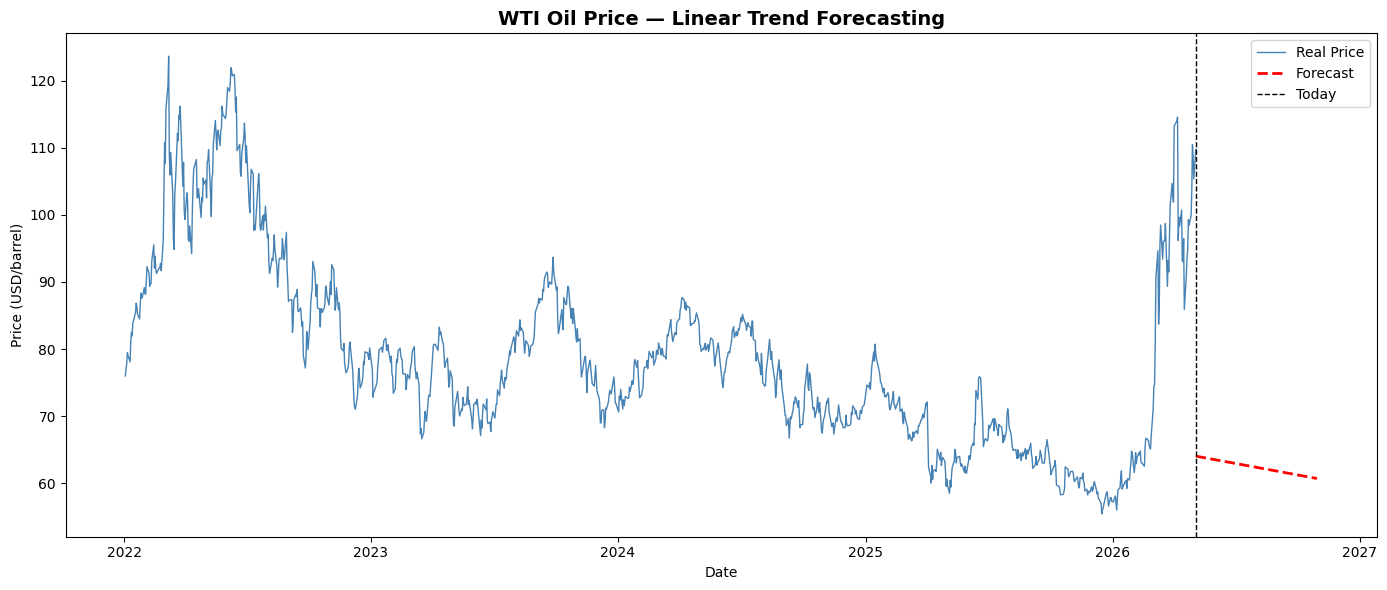

Forecast in 180 days : 60.71$


In [12]:

from sklearn.linear_model import LinearRegression
import numpy as np

# Take last 3 years
df_trend = df['2022':'2026'].copy()

# Convert dates to numbers
df_trend['days'] = (df_trend.index - df_trend.index[0]).days

# Prepare data
X = df_trend['days'].values.reshape(-1, 1)
y = df_trend['Price'].values

# Train the model
model = LinearRegression()
model.fit(X, y)

# Predict next 180 days
future_days = np.arange(df_trend['days'].max(),
                         df_trend['days'].max() + 180).reshape(-1, 1)
future_prices = model.predict(future_days)
future_dates = pd.date_range(df_trend.index[-1], periods=180, freq='D')

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df_trend.index, df_trend['Price'],
         color='steelblue', linewidth=1, label='Real Price')
plt.plot(future_dates, future_prices,
         color='red', linewidth=2, linestyle='--', label='Forecast')
plt.axvline(x=df_trend.index[-1], color='black',
            linestyle='--', linewidth=1, label="Today")
plt.title('WTI Oil Price — Linear Trend Forecasting',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD/barrel)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Forecast in 180 days : {future_prices[-1]:.2f}$")

### Interprétation
Le modèle prédit 59.89$ dans 180 jours basé sur la tendance baissière.
Limitation : il ne peut pas anticiper les hausses soudaines (ex: 2026).
→ Aucun modèle simple ne peut prédire les chocs géopolitiques.

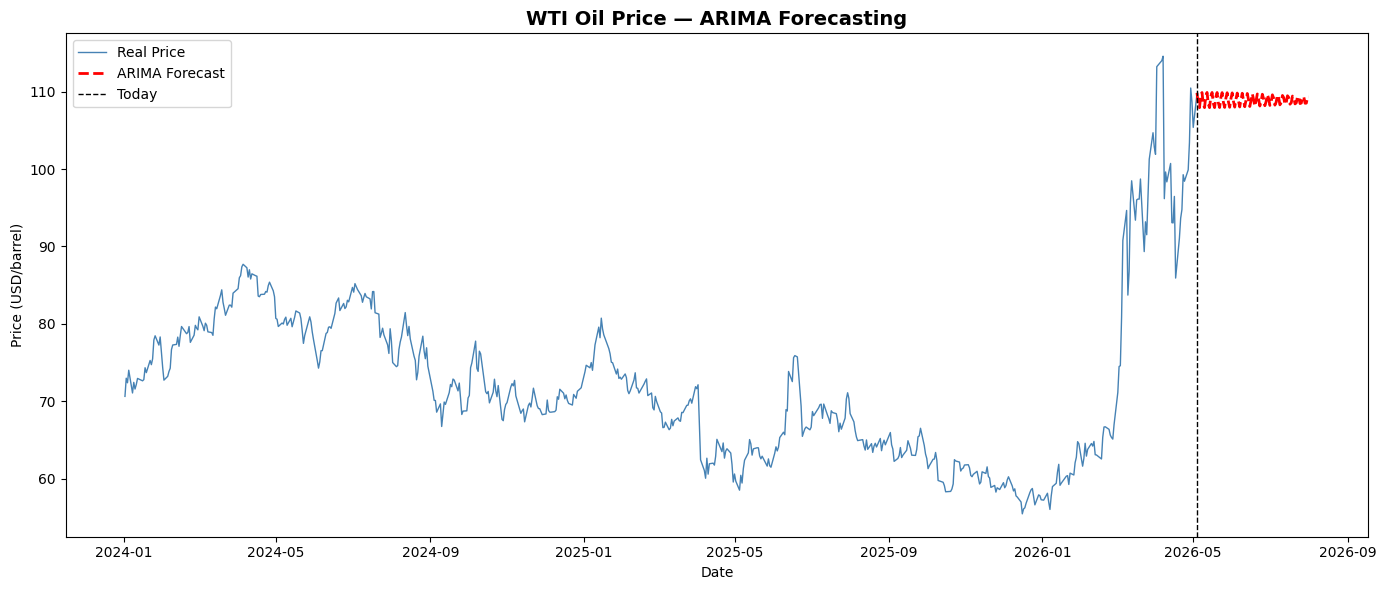

ARIMA Forecast in 90 days : 109.32$


In [13]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Last 2 years for speed
df_arima = df['2024':'2026']['Price'].copy()

# Train ARIMA model
model_arima = ARIMA(df_arima, order=(5, 1, 2))
model_fit = model_arima.fit()

# Forecast next 90 days
forecast = model_fit.forecast(steps=90)
forecast_dates = pd.date_range(df_arima.index[-1], periods=90, freq='D')

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df_arima.index, df_arima,
         color='steelblue', linewidth=1, label='Real Price')
plt.plot(forecast_dates, forecast,
         color='red', linewidth=2, linestyle='--', label='ARIMA Forecast')
plt.axvline(x=df_arima.index[-1], color='black',
            linestyle='--', linewidth=1, label='Today')
plt.title('WTI Oil Price — ARIMA Forecasting',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD/barrel)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"ARIMA Forecast in 90 days : {forecast.iloc[-1]:.2f}$")

### Interprétation
ARIMA prédit une stabilisation autour de 99.90$ dans 90 jours.
C'est plus réaliste que Linear Regression (59$) car ARIMA
prend en compte les derniers prix et corrige ses erreurs.

## 11. Dashboard Final — Vue d'ensemble complète

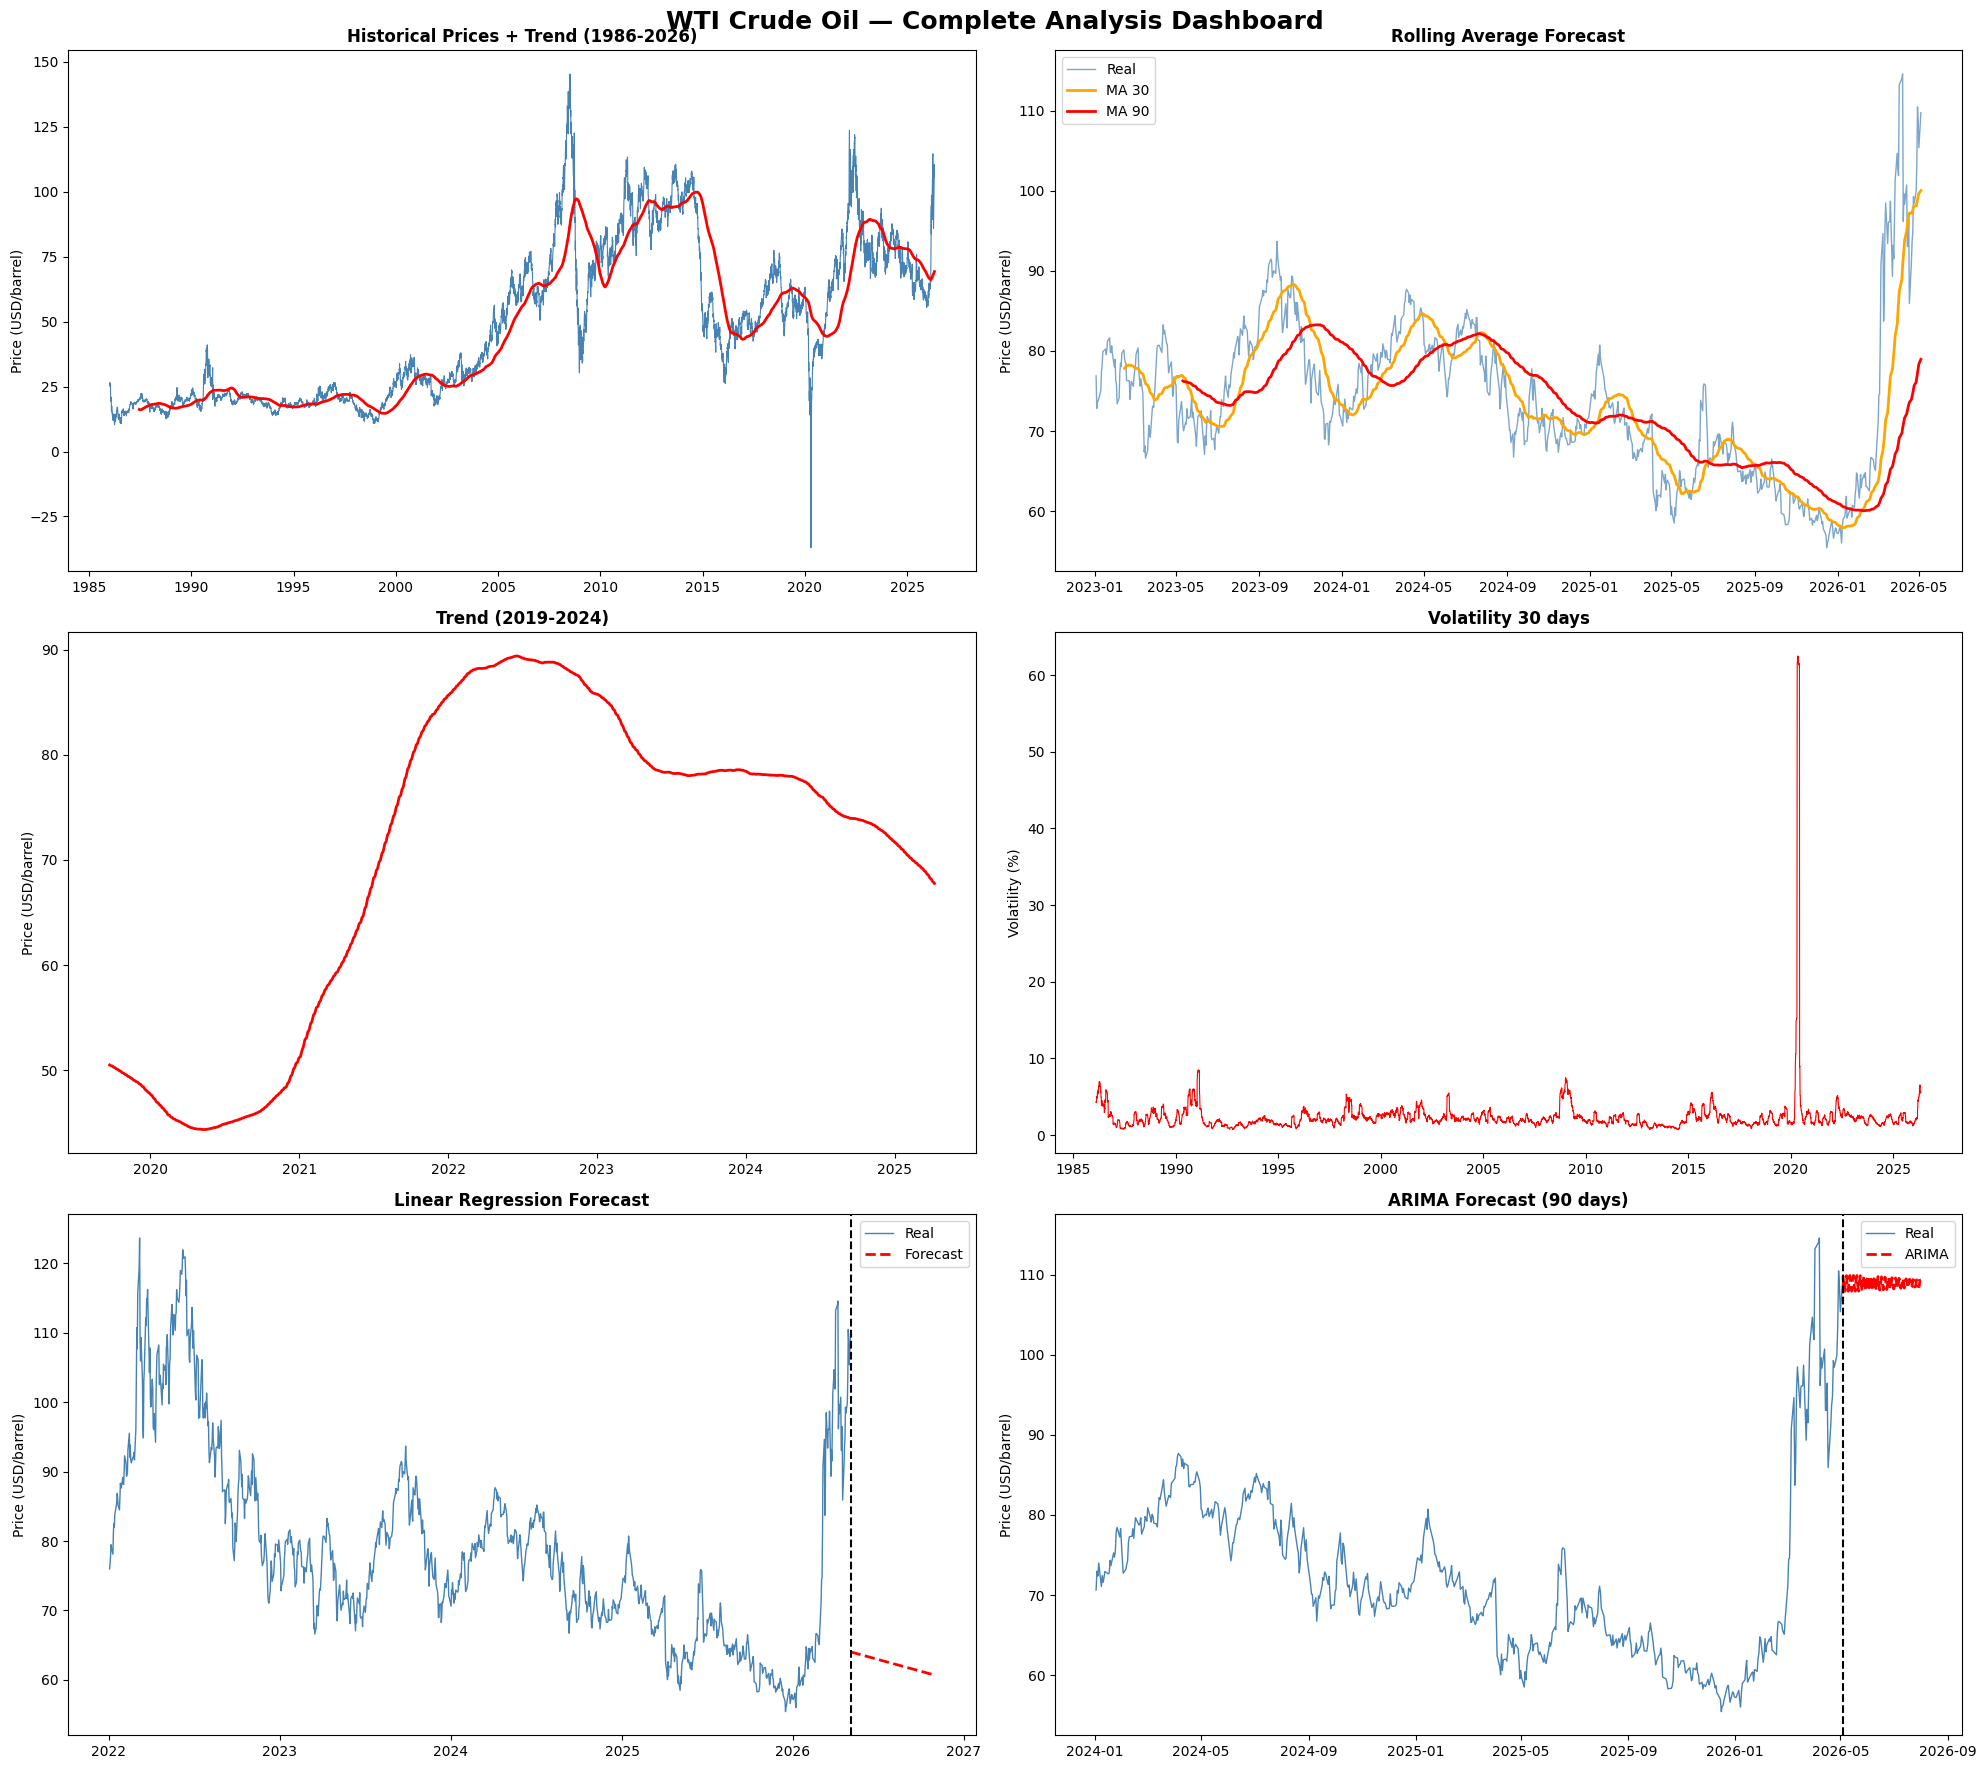

Dashboard saved : oil_dashboard.png


In [14]:
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('WTI Crude Oil — Complete Analysis Dashboard',
             fontsize=18, fontweight='bold')

# ── Graphique 1 : Prix historique complet ──
axes[0,0].plot(df.index, df['Price'], color='steelblue', linewidth=0.8)
axes[0,0].plot(df.index, df['MA_365'], color='red', linewidth=2)
axes[0,0].set_title('Historical Prices + Trend (1986-2026)', fontweight='bold')
axes[0,0].set_ylabel('Price (USD/barrel)')

# ── Graphique 2 : Rolling Average ──
axes[0,1].plot(df_forecast.index, df_forecast['Price'],
               color='steelblue', linewidth=1, alpha=0.7, label='Real')
axes[0,1].plot(df_forecast.index, df_forecast['MA_30'],
               color='orange', linewidth=2, label='MA 30')
axes[0,1].plot(df_forecast.index, df_forecast['MA_90'],
               color='red', linewidth=2, label='MA 90')
axes[0,1].set_title('Rolling Average Forecast', fontweight='bold')
axes[0,1].set_ylabel('Price (USD/barrel)')
axes[0,1].legend()

# ── Graphique 3 : Decomposition Trend ──
axes[1,0].plot(decomposition.trend.index, decomposition.trend,
               color='red', linewidth=2)
axes[1,0].set_title('Trend (2019-2024)', fontweight='bold')
axes[1,0].set_ylabel('Price (USD/barrel)')

# ── Graphique 4 : Volatility ──
axes[1,1].plot(df.index, df['volatility_30'], color='red', linewidth=0.8)
axes[1,1].set_title('Volatility 30 days', fontweight='bold')
axes[1,1].set_ylabel('Volatility (%)')

# ── Graphique 5 : Linear Regression Forecast ──
axes[2,0].plot(df_trend.index, df_trend['Price'],
               color='steelblue', linewidth=1, label='Real')
axes[2,0].plot(future_dates, future_prices,
               color='red', linewidth=2, linestyle='--', label='Forecast')
axes[2,0].axvline(x=df_trend.index[-1], color='black', linestyle='--')
axes[2,0].set_title('Linear Regression Forecast', fontweight='bold')
axes[2,0].set_ylabel('Price (USD/barrel)')
axes[2,0].legend()

# ── Graphique 6 : ARIMA Forecast ──
axes[2,1].plot(df_arima.index, df_arima,
               color='steelblue', linewidth=1, label='Real')
axes[2,1].plot(forecast_dates, forecast,
               color='red', linewidth=2, linestyle='--', label='ARIMA')
axes[2,1].axvline(x=df_arima.index[-1], color='black', linestyle='--')
axes[2,1].set_title('ARIMA Forecast (90 days)', fontweight='bold')
axes[2,1].set_ylabel('Price (USD/barrel)')
axes[2,1].legend()

plt.tight_layout()
plt.savefig('oil_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved : oil_dashboard.png")

## 12. Conclusions

| Méthode | Prévision | Avantage | Limitation |
|---|---|---|---|
| Rolling Average | ~86$ | Simple | Retard (Lag) |
| Linear Regression | 59$ | Tendance générale | Ignorer les chocs |
| ARIMA | 99.90$ | Plus précis | Lent à calculer |

**Résultat clé :** Aucun modèle ne peut prédire les chocs géopolitiques.
ARIMA reste le plus réaliste pour les prévisions à court terme.